In [1]:
import torch
import pandas as pd
from torch import nn

In [2]:
# 加载 autoreload 扩展插件
%load_ext autoreload

# 自动重载所有修改过的模块
%autoreload 2

%reload_ext autoreload

In [3]:
# 未清理平行语句
OriDataDir = "./data/jpn.txt"

# 清理后储存位置
CleanedDataDir = "./data/cleaned.txt"
SecondPartData = "./data/日语-英语.tsv"
JaTokensFile = "./data/JaTokens.pkl"
EnTokensFile = "./data/EnTokens.pkl"

In [4]:
# 数据清理
def clean_data(input_file, output_file, min_len = 0, max_len = 200):
    cleaned = []

    with open(input_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            parts = line.split("\t")

            if max_len > len(parts[1]) > min_len:
                cleaned.append(parts[1] + '\t' + parts[0])

    with open(output_file, "w", encoding="utf-8") as f:
        for line in cleaned:
            f.write(line + '\n')

    print("cleaned up")

# clean_data(OriDataDir, CleanedDataDir)


In [5]:
# 读入平行语录
Source = []
Target = []

# 读上方处理过的txt文件
with open(CleanedDataDir, "r", encoding = "utf-8") as f:
    for line in f:
        line = line.strip()
        parts = line.split('\t')
        Source.append(parts[0])
        Target.append(parts[1])


# 处理第二部分tsv文件, 分隔符为'\t'，把引号当成普通字符串处理
pd_tsv = pd.read_csv(SecondPartData, sep = "\t", quoting=3, header=None).fillna("")
SecondPartJA = pd_tsv.iloc[:, 1].tolist()
SecondPartEN = pd_tsv.iloc[:, 3].tolist()
Source = Source + SecondPartJA
Target = Target + SecondPartEN

print(len(Source))
print(len(Target))


393079
393079


In [6]:
# 日语分词,CPU密集任务，多进程跑。
# ipynb文件不易运行多进程，模块分离到 my_tokenize.py里


In [7]:
# pickle反序列化读取token
import pickle

JaTokens = pickle.load(open(JaTokensFile, "rb"))
EnTokens = pickle.load(open(EnTokensFile, "rb"))

print(len(JaTokens))
print(len(EnTokens))

print(JaTokens[-10:])
print(EnTokens[-10:])


393079
393079
[['夕暮れ', 'の', '商店', '街', 'を', '歩く', 'と', '、', 'どこ', 'か', '懐かしい', '気持ち', 'に', 'なる', '。'], ['この', '作家', 'の', '文体', 'は', '独特', 'で', '、', '一度', '読ん', 'だら', '忘れ', 'られ', 'ない', '。'], ['技術', 'が', '追いつく', 'まで', 'に', '5', '年', 'は', 'かかる', 'だろ', 'う', '。'], ['しかし', '生存', '者', '達', 'は', '、', 'その', '事実', 'を', '知ら', 'なかっ', 'た', '。'], ['物理', '学', 'は', '難しい', 'です', '。'], ['物理', 'は', '難しい', '。'], ['映画', '館', 'に', '行か', 'なかっ', 'た', 'よ', '。'], ['アメリカ', 'で', '行わ', 'れ', 'た', '全国', '的', 'な', '世論', '調査', 'に', 'よる', 'と', '、', 'イスラム', '教徒', 'が', 'テロリズム', 'と', '関連', 'し', 'て', 'いる', 'という', '考え', 'が', '広く', '浸透', 'し', 'て', 'いる', '。'], ['彼女', 'は', 'ネコ', 'が', '大好き', 'だ', '。'], ['説明', 'に', 'なっ', 'て', 'なく', 'ね', '？']]
[['There', "'s", 'something', 'nostalgic', 'about', 'walking', 'the', 'shopping', 'district', 'in', 'the', 'evening', '.'], ['This', 'author', "'s", 'writing', 'style', 'is', 'unique', ';', 'once', 'you', 'read', 'it', ',', 'you', "'ll", 'never', 'forget', '.'], ['It', 'must', 'be', 'five',

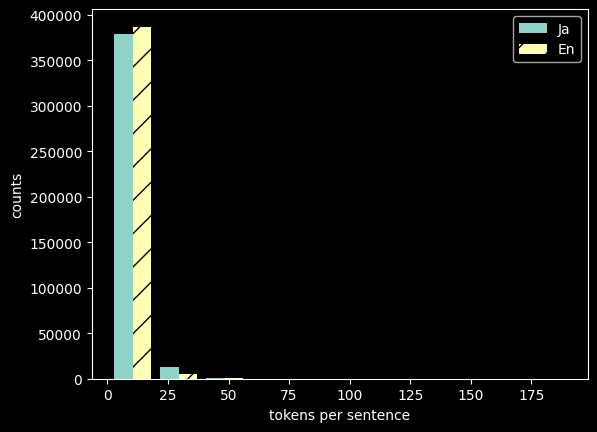

In [8]:
# 绘制每个文本包含的词元数量图
import matplotlib.pyplot as plt

def block(xlist, ylist, xlabel, ylabel, legend):


    plt.xlabel(xlabel)
    plt.ylabel(ylabel)


    # plt.hist() 返回一个元组 (n, bins, patches)。
    # n: 每个 bin 中的数据量（数值）。
    # bins: 长方形的数值边界。
    # patches: 直方图的条形对象，这是我们需要的。
    # label 参数用于指定图例。
    _,__, patches = plt.hist([xlist, ylist],label = legend)
    for patch in patches[1]:
        patch.set_hatch('/')

    plt.legend()
    plt.show()

JaLenPerSentence = [len(s) for s in JaTokens]
EnLenPerSentence = [len(s) for s in EnTokens]

block(
    JaLenPerSentence,
    EnLenPerSentence,
    "tokens per sentence",
    "counts",
    ["Ja","En"]
)


In [9]:
from vocab import Vocabulary

JaVocab = Vocabulary(JaTokens, min_freq= 1, reserved_tokens= ["<pad>","<bos>","<eos>"])
EnVocab = Vocabulary(EnTokens, min_freq= 1, reserved_tokens= ["<pad>","<bos>","<eos>"])

print(len(JaVocab))
print(len(EnVocab))

38784
32003


In [10]:
# 截断长度太长的，填充长度不够的
def truncate(sentence, num_steps, padding):
    if len(sentence) > num_steps:
        return sentence[:num_steps]
    return sentence + [padding] * (num_steps - len(sentence))

print(truncate(JaVocab[JaTokens[0]],75, JaVocab["<pad>"]))

[534, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [11]:
# 把token序列映射成数值
JaTokensId = []
EnTokensId = []

for i in range(len(JaTokens)):
    JaTokensId.append(JaVocab[JaTokens[i]])
    EnTokensId.append(EnVocab[EnTokens[i]])

print(len(JaTokensId))
print(len(EnTokensId))
print(JaTokensId[0])
print(EnTokensId[0])

393079
393079
[534, 4]
[850, 4]


In [12]:
num_steps = 75

In [13]:
# 转为数据集
import TextDataset

FullDataset = TextDataset.TextDataset(JaTokensId, EnTokensId, num_steps, JaVocab, EnVocab)

print(FullDataset)

In [14]:
print(len(FullDataset))
print(FullDataset[0])

393079
(tensor([  2, 534,   4,   3,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1]), tensor([  2, 850,   4,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1]), tensor([850,   4,   3,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,  

In [15]:
# 一年前写的随机切片

# import numpy as np
#
# TrainSize = int(0.8*len(JaTokensId))    #转为整数
# ValidSize = len(JaTokensId) - TrainSize
#
# np.random.seed(114514)
# FullIdx = np.random.permutation(len(JaTokensId))
#
# TrainIdx = FullIdx[:TrainSize]
# ValidIdx = FullIdx[TrainSize:]
#
#
# JaTrainTokensId = [JaTokensId[i] for i in TrainIdx]
# EnTrainTokensId = [EnTokensId[i] for i in TrainIdx]
# JaValidTokensId = [JaTokensId[i] for i in ValidIdx]
# EnValidTokensId = [EnTokensId[i] for i in ValidIdx]
#
#
# TrainDataset = TextDataset.TextDataset(JaTrainTokensId, EnTrainTokensId, num_steps, JaVocab, EnVocab)
# ValidDataset = TextDataset.TextDataset(JaValidTokensId, EnValidTokensId, num_steps, JaVocab, EnVocab)
#
# print(len(TrainDataset))
# print(len(ValidDataset))


In [16]:
# 现代版本的随机切片

from torch.utils.data import random_split

total_size = len(FullDataset)
valid_size = 5000
test_size = 3000
train_size = total_size - valid_size - test_size

generator = torch.Generator().manual_seed(114514)
TrainDataset, ValidDataset, TestDataset = random_split(FullDataset, [train_size, valid_size, test_size], generator)

print(len(TrainDataset))
print(len(ValidDataset))

385079
5000


In [17]:
# 初始化模型
from torch.utils.data import DataLoader
import models.TransformerEncoder as TransformerEncoder
import models.TransformerDecoder as TransformerDecoder

JaVocabLen = len(JaVocab)
EnVocabLen = len(EnVocab)

# transformer参数
d_model = 384
layers = 6
num_heads = 8
dropout = 0.2
d_ff = 1536
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 训练参数
batch_size = 256
steps = 75
epoches = 200



In [18]:
Encoder = TransformerEncoder.TransformerEncoder(vocab_size=JaVocabLen, d_model=d_model, layers=layers, num_heads=num_heads, d_ff=d_ff, dropout=dropout).to(device = device)
Decoder = TransformerDecoder.TransformerDecoder(vocab_size=EnVocabLen, d_model=d_model, layers=layers, num_heads=num_heads, d_ff=d_ff, dropout=dropout).to(device = device)

# 创建dataset的时候数据集已经打乱过了
TrainDataLoader = DataLoader(TrainDataset, batch_size=batch_size, shuffle=False, num_workers=0)
ValidDataLoader = DataLoader(ValidDataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [19]:
import tqdm
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

Pad = EnVocab["<pad>"]
LossFunction = nn.CrossEntropyLoss(reduction="mean", ignore_index=Pad)
Optimizer = torch.optim.Adam(list(Encoder.parameters()) + list(Decoder.parameters()), lr=0.001)

BestScore = 0
TrainLossAll = []
ValidBleuAll = []
EpochNoImprove = 0
Patience = 2
WarmupUpSteps = 4000
GlobalStep = 0

for epoch in range(epoches):
    TrainBlocker = tqdm.tqdm(TrainDataLoader)
    TrainLossEpoch = 0

    Encoder.train()
    Decoder.train()

    for TrainSourceTensors, TrainTargetTensors, TrainLabelTensors, TrainSourceValidLengths, TrainTargetValidLengths in TrainBlocker:
        # warmup
        GlobalStep += 1
        lr = (d_model**-0.5)*min(GlobalStep**-0.5, GlobalStep * (WarmupUpSteps**-1.5))

        for param_group in Optimizer.param_groups:
            param_group['lr'] = lr

        TrainSourceTensors = TrainSourceTensors.to(device)
        TrainTargetTensors = TrainTargetTensors.to(device)
        TrainLabelTensors = TrainLabelTensors.to(device)
        TrainSourceValidLengths = TrainSourceValidLengths.to(device)
        TrainTargetValidLengths = TrainTargetValidLengths.to(device)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            EncoderOutput = Encoder(TrainSourceTensors, TrainSourceValidLengths)
            State = Decoder.init_state(EncoderOutput, TrainSourceValidLengths, TrainTargetValidLengths)

            # 输出(batch_size, steps, EnVocabSize)
            Prediction, _ = Decoder(TrainTargetTensors, State)
            Prediction = Prediction.reshape(-1, Prediction.shape[-1])

            Labels = TrainLabelTensors.reshape(-1)
            Loss = LossFunction(Prediction, Labels)

        TrainLossEpoch += Loss.item()

        Optimizer.zero_grad()
        Loss.backward()
        torch.nn.utils.clip_grad_norm_(list(Encoder.parameters()) + list(Decoder.parameters()), 1.0)

        Optimizer.step()
        TrainBlocker.set_postfix(epoch=epoch, Loss=Loss.item())

    TrainLossAll.append(TrainLossEpoch)


    Encoder.eval()
    Decoder.eval()

    BleuEpoch = []
    ValidBlocker = tqdm.tqdm(ValidDataLoader)

    with torch.no_grad():
        for ValidSourceTensors, ValidTargetTensors, ValidLabelTensors, ValidSourceValidLengths, ValidTargetValidLengths in ValidBlocker:

            Bos = EnVocab["<bos>"]
            Eos = EnVocab["<eos>"]
            Pad = EnVocab["<pad>"]

            ValidSourceTensors = ValidSourceTensors.to(device)
            ValidTargetTensors = ValidTargetTensors.to(device)
            ValidLabelTensors = ValidLabelTensors.to(device)
            ValidSourceValidLengths = ValidSourceValidLengths.to(device)
            ValidTargetValidLengths = ValidTargetValidLengths.to(device)

            with torch.amp.autocast('cuda', dtype=torch.bfloat16):

                EncoderOutput = Encoder(ValidSourceTensors, ValidSourceValidLengths)
                State = Decoder.init_state(EncoderOutput, ValidSourceValidLengths, ValidTargetValidLengths)

                DecoderInput = torch.full((ValidSourceTensors.shape[0], 1), Bos, dtype=torch.long, device=device)
                PredictionALl = []
                Finished = torch.zeros(ValidSourceTensors.shape[0], dtype=torch.bool, device=device)
                MaxLen = 100
                for i in range(MaxLen):
                    # 输出(batch_size, 1, vocab)
                    Prediction, State = Decoder(DecoderInput, State)
                    Prediction = Prediction.argmax(dim=-1)
                    PredictionALl.append(Prediction)

                    Finished |= (Prediction.squeeze(-1) == Eos)
                    DecoderInput = Prediction

                    if Finished.all():
                        break

            Sentence = torch.stack(PredictionALl, dim=1).reshape(ValidSourceTensors.shape[0], len(PredictionALl))

            for j in range(Sentence.shape[0]):
                EosIdx = torch.where(Sentence[j, :] == Eos)[0]

                if EosIdx.numel() > 0:
                    FirstEosIdx = EosIdx[0].item()
                    Sentence[j, FirstEosIdx + 1:] = Pad


            BleuBatch = []
            SentenceList = Sentence.tolist()
            LabelList = ValidLabelTensors.tolist()

            IdxToToken = EnVocab.id_to_token
            Smooth = SmoothingFunction().method1

            for PredictionIdx, LabelIdx in zip(SentenceList, LabelList):

                # 转为词
                SentenceWords= []
                LabelWords = []

                for idx in PredictionIdx:
                    if idx == Eos:
                        break
                    if idx not in (Bos,Pad):
                        SentenceWords.append(IdxToToken[idx])

                for idx in LabelIdx:
                    if idx == Eos:
                        break
                    if idx not in (Bos,Pad):
                        LabelWords.append(IdxToToken[idx])


                if SentenceWords and LabelWords:
                    Score = sentence_bleu([LabelWords], SentenceWords, smoothing_function=Smooth)
                    BleuBatch.append(Score)

            BleuEpoch.append(sum(BleuBatch) / len(BleuBatch))

            ValidBlocker.set_postfix(epoch=epoch, bleu=sum(BleuBatch) / len(BleuBatch))

        BleuAve = sum(BleuEpoch) / len(BleuEpoch)
        ValidBleuAll.append(BleuAve)

        # early stopping
        if BleuAve > BestScore + 0.002:
            EpochNoImprove = 0
            print(BleuAve)
            torch.save(Encoder.state_dict(), "result/3/Encoder.pth")
            torch.save(Decoder.state_dict(), "result/3/Decoder.pth")
            print(f'epoch {epoch} saved')
            BestScore = BleuAve

        else:
            EpochNoImprove = EpochNoImprove + 1

    if EpochNoImprove > Patience:
        print("Early Stopping")
        break


Early Stopping


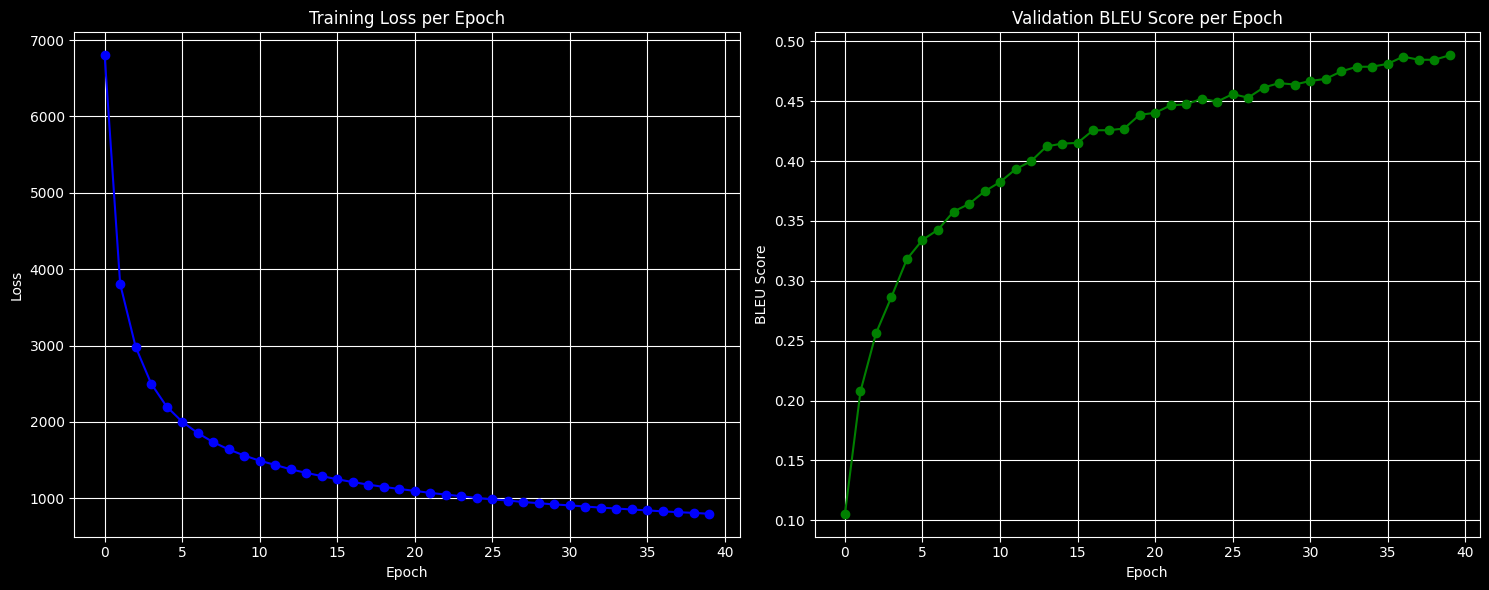

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
print(TrainLossAll)
print(ValidBleuAll)
# 绘制训练损失图
ax1.plot(TrainLossAll, marker='o', linestyle='-', color='b')
ax1.set_title('Training Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# 绘制验证 BLEU 图
ax2.plot(ValidBleuAll, marker='o', linestyle='-', color='g')
ax2.set_title('Validation BLEU Score per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('BLEU Score')
ax2.grid(True)

# 显示图表
plt.tight_layout()
plt.show()

# 保存图片
fig.savefig('.//result//3//training_validation_plots.png')

In [21]:
with open("./result/3/TrainScore.txt", "w") as f:
    f.write("Epoch\tBLEU:\n")
    epoch = 1
    for Bleu in ValidBleuAll:
        f.write(f"epoch{epoch}:\t{Bleu}\n")
        epoch += 1

    epoch = 1

    f.write("Epoch\tLoss:\n")
    for Loss in TrainLossAll:
        f.write(f"epoch{epoch}:\t{Loss}\n")
        epoch += 1
    f.close()


In [24]:
import sys
import Bleu

TestDataLoader = DataLoader(TestDataset, batch_size=batch_size, shuffle=False, num_workers=0)
print(len(TestDataLoader))


NewEncoder = TransformerEncoder.TransformerEncoder(vocab_size=JaVocabLen, d_model=d_model, layers=layers, num_heads=num_heads, d_ff=d_ff, dropout=dropout).to(device = device)
NewDecoder = TransformerDecoder.TransformerDecoder(vocab_size=EnVocabLen, d_model=d_model, layers=layers, num_heads=num_heads, d_ff=d_ff, dropout=dropout).to(device = device)






NewEncoderPath = "result/3/Encoder.pth"
NewDecoderPath = "result/3/Decoder.pth"


NewEncoder.load_state_dict(torch.load(NewEncoderPath, map_location=device))
NewDecoder.load_state_dict(torch.load(NewDecoderPath, map_location=device))


NewBleu = Bleu.evaluate_bleu(NewEncoder, NewDecoder, TestDataLoader, EnVocab, device)


print(f"{NewBleu:.5f}")

0.47770


In [25]:
def translate(source, device, encoder, decoder, j_tokenizer,vocab_source,vocab_target):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():

        word_token = []

        tokens = j_tokenizer.tokenize(source)
        for token in tokens:
            parts = str(token).split('\t')
            word_token.append(parts[0])

        word_token.append('<eos>')
        word_index = vocab_source[word_token]
        valid_lens = torch.tensor([len(word_index)], dtype=torch.long, device=device)
        print(word_token)

        encoder_tensor = torch.tensor(word_index,dtype=torch.long,device=device).reshape(1,len(word_index))
        encoder_outputs = encoder(encoder_tensor, valid_lens)
        decoder_state = decoder.init_state(encoder_outputs, valid_lens)


        begin = [vocab_source['<bos>']]
        begin_tensor = torch.tensor(begin,dtype=torch.long,device=device).reshape(1,1)

        decode_input = begin_tensor
        predict_token = []
        idx_to_token = vocab_target.id_to_token


        for i in range(num_steps):
            decode_output, decoder_state = decoder(decode_input, decoder_state)
            next_token = decode_output.argmax(dim = -1)
            predict_token.append(next_token)
            decode_input = next_token

        eos_token_id = vocab_target['<eos>']
        eos_index = predict_token.index(eos_token_id)
        clean = predict_token[:eos_index]

        predict_words = [idx_to_token[idx] for idx in clean]

        return ' '.join(predict_words)


In [27]:
from janome.tokenizer import Tokenizer

j_tokenizer = Tokenizer()

source = "彼が昨日図書館で借りてきた難しい本は、もうみんなに読まれている。"
target = translate(source, device=device,encoder=NewEncoder, decoder=NewDecoder,j_tokenizer=j_tokenizer,vocab_source=JaVocab, vocab_target=EnVocab)

print(target)

He borrowed books in the library yesterday , but he is now difficult to read , and yet he is now being borrowed by everyone in the library .
